In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("ML-8 Decision Tree Resources 16936475981.txt")

In [3]:
data

,company,job,degree,salary_more_then_50000
0,Reliance,sales executive,bachelors,0
1,Reliance,sales executive,masters,0
2,Reliance,business manager,bachelors,1
3,Reliance,business manager,masters,1
4,Reliance,computer programmer,bachelors,0
5,Reliance,computer programmer,masters,1
6,Torrent,sales executive,masters,0
7,Torrent,computer programmer,bachelors,0
8,Torrent,business manager,bachelors,0
9,Torrent,business manager,masters,1


In [4]:
x = data.drop("salary_more_then_50000",axis=1)

In [5]:
x

,company,job,degree
0,Reliance,sales executive,bachelors
1,Reliance,sales executive,masters
2,Reliance,business manager,bachelors
3,Reliance,business manager,masters
4,Reliance,computer programmer,bachelors
5,Reliance,computer programmer,masters
6,Torrent,sales executive,masters
7,Torrent,computer programmer,bachelors
8,Torrent,business manager,bachelors
9,Torrent,business manager,masters


In [6]:
y = data["salary_more_then_50000"]

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
labelen = LabelEncoder()

In [9]:
x = x.apply(labelen.fit_transform)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=40)

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
model = DecisionTreeClassifier()

In [14]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [15]:
y_pri = model.predict(x_test)

In [16]:
model.score(x_train,y_train)*100

100.0

In [17]:
model.score(x_test,y_test)*100

100.0

In [18]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [19]:
accuracy_score(y_test,y_pri)*100

100.0

In [21]:
con = confusion_matrix(y_test,y_pri)

In [22]:
con

array([[1, 0],
       [0, 4]], dtype=int64)

<Axes: >

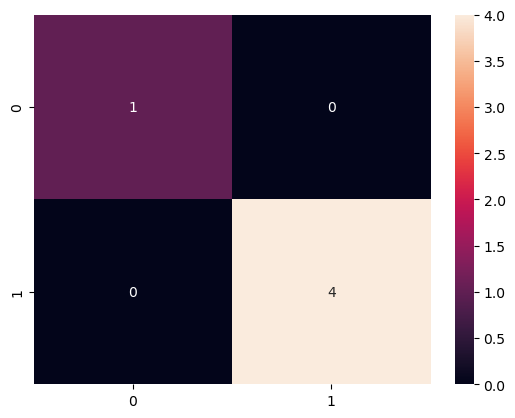

In [23]:
sns.heatmap(con,annot=True)

In [24]:
print(classification_report(y_test,y_pri))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [25]:
from sklearn.tree import export_text

In [26]:
        print(export_text(model))

|--- feature_0 <= 1.50
|   |--- feature_0 <= 0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 1
|   |   |--- feature_1 >  0.50
|   |   |   |--- feature_1 <= 1.50
|   |   |   |   |--- feature_2 <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_2 >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- feature_1 >  1.50
|   |   |   |   |--- class: 0
|   |--- feature_0 >  0.50
|   |   |--- class: 1
|--- feature_0 >  1.50
|   |--- feature_2 <= 0.50
|   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_1 <= 1.00
|   |   |   |--- class: 1
|   |   |--- feature_1 >  1.00
|   |   |   |--- class: 0



In [27]:
from sklearn.tree import plot_tree

<function matplotlib.pyplot.show(close=None, block=None)>

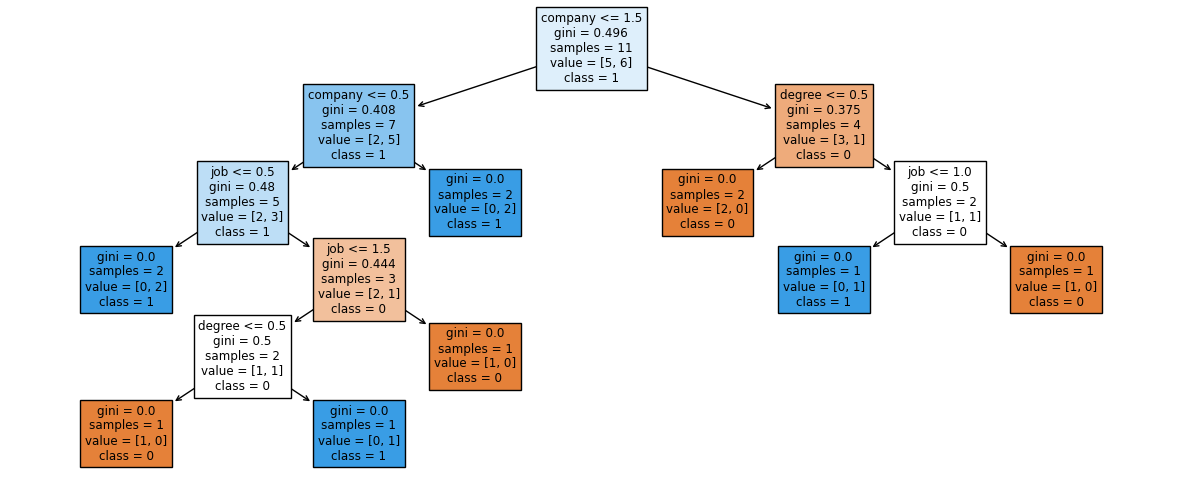

In [34]:
plt.figure(figsize=(15,6))
plot_tree(model,feature_names=x.columns,class_names=["0","1"],filled=True)
plt.show